In [9]:

import MDAnalysis as mda
from MDAnalysis.analysis import distances
import matplotlib.pyplot as plt
import numpy as np

/usr/local/lib/python3.6/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
def count_water_near_residue(trajectory_file, topology_file, residue_name, distance_cutoff=5.0):
    """
    Count the number of water molecules near a specific residue in each frame of the trajectory.

    Parameters:
    - trajectory_file (str): Path to the trajectory file (e.g., NC).
    - topology_file (str): Path to the topology file (e.g., PRMTOP).
    - residue_name (str): Residue name to analyze (e.g., 'FE1').
    - distance_cutoff (float): Distance cutoff in angstroms to consider water molecules near the residue.

    Returns:
    - water_counts (list): List of counts of water molecules near the residue for each frame.
    """
    # Load the trajectory
    u = mda.Universe(topology_file, trajectory_file)
    
    # Select the residue and water molecules
    residue = u.select_atoms(f"resname {residue_name}")
    water_oxygen = u.select_atoms("resname WAT and name O")

    water_counts = []

    # Iterate over each frame
    for ts in u.trajectory:
        # Calculate distances between the residue and water oxygens
        d = distances.distance_array(residue.positions, water_oxygen.positions, box=ts.dimensions)
        
        # Count water molecules within the distance cutoff
        count = np.sum(np.any(d < distance_cutoff, axis=0))
        water_counts.append(count)

    return water_counts


In [ ]:
def plot_histogram(water_counts, output_file="water_histogram.png"):
    """
    Plot a histogram of the number of water molecules near the residue.

    Parameters:
    - water_counts (list): List of counts of water molecules near the residue for each frame.
    - output_file (str): Path to save the histogram plot.
    """
    plt.figure(figsize=(10, 6))
    plt.hist(water_counts, bins=np.arange(0, 6) - 0.5, edgecolor='black', range=(0, 5))
    plt.xlabel("Number of Water Molecules")
    plt.ylabel("Number of Snapshots")
    plt.title("Histogram of Water Molecules Near Residue (0 to 4)")
    plt.xticks(np.arange(0, 5, 1))  # Set x-ticks to 0, 1, 2, 3, 4
    plt.grid(False)
    plt.savefig(output_file)
    plt.show()

In [ ]:
def plot_histogram(water_counts, output_file="water_histogram.png"):
    """
    Plot a histogram of the number of water molecules near the residue.

    Parameters:
    - water_counts (list): List of counts of water molecules near the residue for each frame.
    - output_file (str): Path to save the histogram plot.
    """
    plt.figure(figsize=(10, 6))
    plt.hist(water_counts, bins=np.arange(0, 6) - 0.5, edgecolor='black', range=(0, 5))
    plt.xlabel("Number of Water Molecules")
    plt.ylabel("Number of Snapshots")
    plt.xticks(np.arange(0, 5, 1))  # Set x-ticks to 0, 1, 2, 3, 4
    plt.grid(False)
    plt.savefig(output_file)
    plt.show()

In [44]:
# Define your files and parameters
trajectory_file = "/mnt/research/bathir/EFE/EFE_WT/EFE-Bollinger-Mechanism/A198L/MD/Analysis/6-md_auto.nc"  # Replace with yourvbdjectory file path
topology_file = "/mnt/research/bathir/EFE/EFE_WT/EFE-Bollinger-Mechanism/A198L/MD/EFE_solv.prmtop"  # Replace with your topology file path
residue_name = "FE1"  # Change this to your residue number
distance_cutoff = 5.0  # Distance cutoff in angstroms
n_jobs = -1  # Number of parallel jobs, -1 uses all available cores

In [45]:
# Get the counts of water molecules near the residue
water_counts = count_water_near_residue(trajectory_file, topology_file, residue_name, distance_cutoff)


In [34]:
def plot_histogram(water_counts, output_file="water_histogram.png"):
    """
    Plot a histogram of the percentage of water molecules near the residue.

    Parameters:
    - water_counts (list): List of counts of water molecules near the residue for each frame.
    - output_file (str): Path to save the histogram plot.
    """
    plt.rcParams['font.family'] = 'Calibri'
    plt.rcParams['font.weight'] = 'bold'
    # Calculate the percentage of frames for each bin
    total_frames = len(water_counts)
    plt.figure(figsize=(16, 9))
    

    font = {'family': 'Calibri', 'weight': 'bold', 'size': 14}
    # Create the histogram, but normalize to get percentage
    counts, bins, _ = plt.hist(water_counts, bins=np.arange(0, 6) - 0.5, edgecolor='black', range=(0, 5), density=True)

    # Convert the density (fraction) to percentage
    counts = counts * 100

    plt.xlabel("Number of Water Molecules", fontdict=font)
    plt.ylabel("Percentage of Trajectory (%)", fontdict=font)
    # plt.title("Percentage of Water Molecules Near Residue (0 to 4)")
    plt.xticks(np.arange(0, 5, 1))  # Set x-ticks to 0, 1, 2, 3, 4
    plt.grid(False)

    plt.savefig(output_file)
    plt.show()

In [40]:
def plot_histogram(water_counts, output_file="water_histogram.png"):
    """
    Plot a histogram of the percentage of water molecules near the residue.

    Parameters:
    - water_counts (list): List of counts of water molecules near the residue for each frame.
    - output_file (str): Path to save the histogram plot.
    """
    plt.rcParams['font.family'] = 'Calibri'
    plt.rcParams['font.weight'] = 'bold'

    # Calculate the percentage of frames for each bin
    total_frames = len(water_counts)
    plt.figure(figsize=(16, 9))
    
    font = {'family': 'Calibri', 'weight': 'bold', 'size': 14}

    # Create the histogram without normalization and calculate percentage manually
    counts, bins = np.histogram(water_counts, bins=np.arange(0, 6) - 0.5, range=(0, 5))

    # Convert the counts to percentage
    counts_percentage = (counts / total_frames) * 100

    # Plot the histogram
    plt.bar(bins[:-1], counts_percentage, width=1, edgecolor='black')

    plt.xlabel("Number of Water Molecules", fontdict=font)
    plt.ylabel("Percentage of Trajectory (%)", fontdict=font)
    plt.xticks(np.arange(0, 5, 1))  # Set x-ticks to 0, 1, 2, 3, 4
    plt.grid(False)

    # Save and display the plot
    plt.savefig(output_file)
    plt.show()

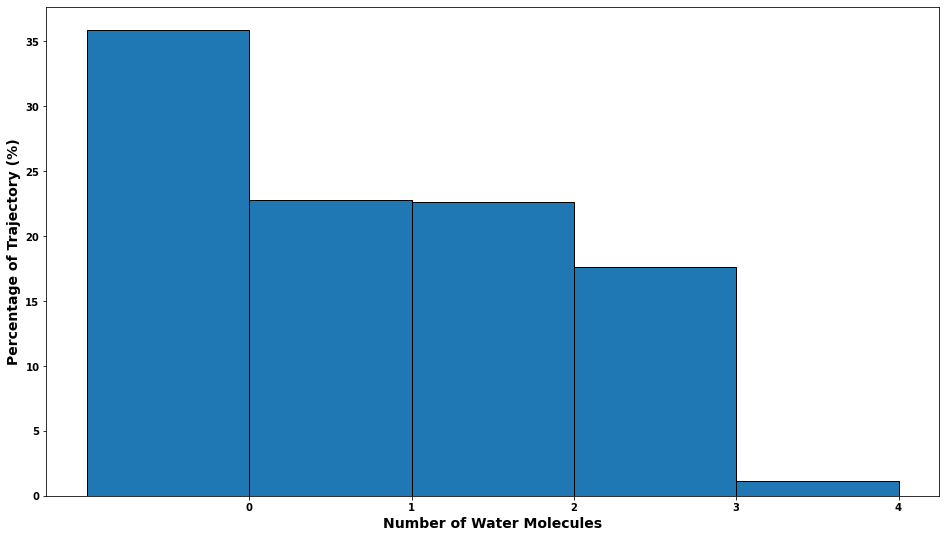

In [46]:
# Plot the histogram
plot_histogram(water_counts, "/mnt/research/bathir/EFE/EFE_WT/EFE-Bollinger-Mechanism/A198L/MD/Analysis/Histogram/water_histogram.png")